### CD8 T-cell Milo Differential Abundance Analysis: Age Effect
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Lineage-specific age-associated neighbourhood differential abundance*

#### Background
Milo identifies local neighbourhoods within the CD8 T-cell manifold that show age-associated changes in abundance while accounting for donor-level covariates and neighbourhood structure.

#### Aim
This notebook tests whether CD8 T-cell neighbourhood abundance changes with donor age using Milo.

*Note: This analysis was performed as a lineage-specific exploration of age-associated compositional changes within CD8 T cells. The primary differential abundance results reported in the thesis were derived from the full-cohort compositional analysis, while Milo was used to provide higher-resolution neighbourhood-level insights.*


In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo

In [2]:
mdata_cd8_age = mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_milo_nhoods_built.h5mu")

In [3]:
mdata_cd8_age

MuData object with n_obs × n_vars = 265696 × 52345
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'ind

## Run Milo Differential Abundance Testing

In [ ]:
# Test for age-associated changes in CD8 neighbourhood abundance
# Batch and sex are included as covariates
milo.da_nhoods(
    mdata_cd8_age,
    design="~ Batch + Sex + Age_years",
    model_contrasts="Age_years",   
    solver="pydeseq2"                  
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 3.05 seconds.

Fitting MAP dispersions...
... done in 3.26 seconds.

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Fitting dispersions...
... done in 5.49 seconds.

Fitting MAP dispersions...
... done in 5.38 seconds.

Fitting dispersions...
... done in 6.23 seconds.

Fitting MAP dispersions...
... done in 5.17 seconds.

Fitting dispersions...
... done in 4.29 seconds.

Fitting MAP dispersions...
... done in 3.90 seconds.

Fitting dispersions...
... done in 4.82 seconds.

Fitting M

Log2 fold change & Wald test p-value: Age_years 17.03 vs 0.05
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      3.695683       -0.612617  0.517210 -1.184465  0.236229  0.331359
1      3.243048       -0.130623  0.654553 -0.199560  0.841825  0.881993
2      7.897237       -0.728721  0.440725 -1.653461  0.098237  0.162313
3      1.929724       -0.512640  0.485892 -1.055051  0.291402  0.392161
4      3.789357        1.950252  0.556348  3.505454  0.000456  0.001698
...         ...             ...       ...       ...       ...       ...
13734  4.077080        1.469387  0.475583  3.089653  0.002004  0.006054
13735  3.581736       -0.397940  0.752269 -0.528986  0.596815  0.685980
13736  4.494113       -0.264892  0.551776 -0.480072  0.631176  0.714546
13737  3.109771       -0.277205  0.455256 -0.608900  0.542591  0.638241
13738  4.271211       -0.895307  0.476259 -1.879875  0.060125  0.108392

[13739 rows x 6 columns]


... done in 1.67 seconds.



In [6]:
mdata_cd8_age["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [7]:
mdata_cd8_age["milo"].uns

{'sample_col': 'pica_id'}

In [ ]:
# Check model output values for basic quality control
print("Model uns:", mdata_cd8_age["milo"].uns)

print("\nlogFC head:")
print(mdata_cd8_age["milo"].var["logFC"].head(10))

print("\nlogFC range:")
print(mdata_cd8_age["milo"].var["logFC"].describe())

print("\nPValue head:")
print(mdata_cd8_age["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0   -0.612617
1   -0.130623
2   -0.728721
3   -0.512640
4    1.950252
5   -1.918207
6    1.120164
7    1.324776
8   -0.942090
9   -1.189622
Name: logFC, dtype: float64

logFC range:
count    13739.000000
mean        -0.233391
std          1.682738
min         -6.670274
25%         -1.363135
50%         -0.170386
75%          0.921518
max          6.063813
Name: logFC, dtype: float64

PValue head:
0    2.362292e-01
1    8.418247e-01
2    9.823704e-02
3    2.914020e-01
4    4.558295e-04
5    3.493895e-07
6    1.598974e-02
7    9.584066e-02
8    9.630807e-02
9    2.469485e-02
Name: PValue, dtype: float64


In [ ]:
# Add donor ID to Milo observation metadata
mdata_cd8_age["milo"].obs["pica_id"] = mdata_cd8_age["milo"].obs.index

In [ ]:
# Create ordered age groups for plotting neighbourhood abundance
mdata_cd8_age["milo"].obs["Age_group"] = pd.cut(
    mdata_cd8_age["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_cd8_age["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd8_age["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [ ]:
# Sample metadata
mdata_cd8_age["milo"].obs

,Age_years,Batch,Sex,pica_id,Age_group
PICA0001,2.09,Batch01,Male,PICA0001,0-3
PICA0002,15.09,Batch01,Male,PICA0002,15-18
PICA0003,0.83,Batch01,Male,PICA0003,0-3
PICA0004,1.46,Batch01,Male,PICA0004,0-3
PICA0005,9.30,Batch01,Male,PICA0005,7-10
...,...,...,...,...,...
PICA0164,2.15,Batch07,Male,PICA0164,0-3
PICA0166,0.62,Batch07,Male,PICA0166,0-3
PICA0168,16.20,Batch07,Male,PICA0168,15-18
PICA0169,2.72,Batch07,Male,PICA0169,0-3


In [ ]:
# Neighbourhood-level Milo results
mdata_cd8_age["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.265390,3.695683,-0.612617,0.236229,0.331359,0.331846
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.257657,3.243048,-0.130623,0.841825,0.881993,0.882227
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.009837,7.897237,-0.728721,0.098237,0.162313,0.162723
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.541760,1.929724,-0.512640,0.291402,0.392161,0.392736
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.219984,3.789357,1.950252,0.000456,0.001698,0.001704
...,...,...,...,...,...,...,...
13734,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.201525,4.077080,1.469387,0.002004,0.006054,0.006076
13735,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.723792,3.581736,-0.397940,0.596815,0.685980,0.686256
13736,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.386278,4.494113,-0.264892,0.631176,0.714546,0.714859
13737,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.204317,3.109771,-0.277205,0.542591,0.638241,0.638533


In [14]:
mdata_cd8_age.write_h5mu("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_age_combined_annot_with_age_nhood.h5mu")

In [ ]:
# Save Milo DA table
mdata_cd8_age["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_milo_age_results.csv")

In [2]:
mdata_cd8_age =mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_age_combined_annot_with_age_nhood.h5mu")

## Milo Model diagnostics

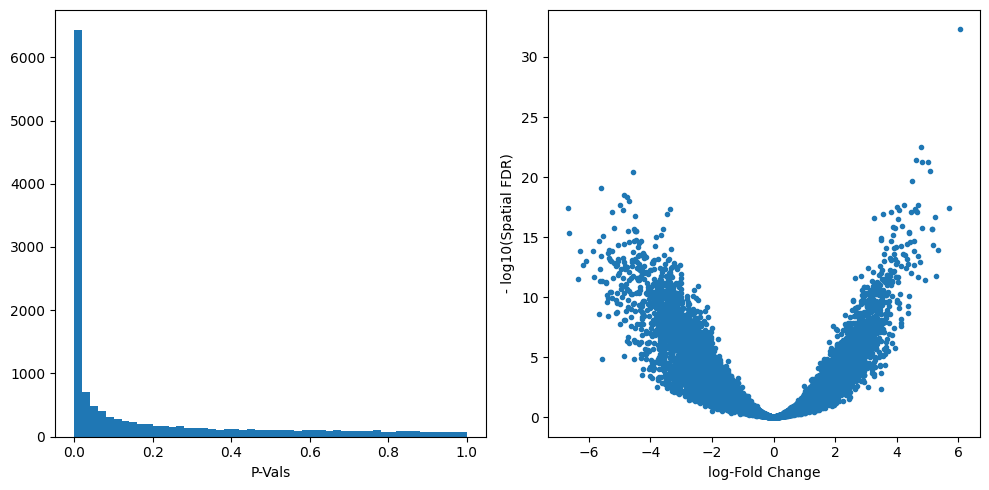

In [ ]:
# Plot p-value distribution and logFC versus spatial FDR for model diagnostics
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd8_age["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd8_age["milo"].var.logFC, -np.log10(mdata_cd8_age["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

<Axes: xlabel='Age_group'>

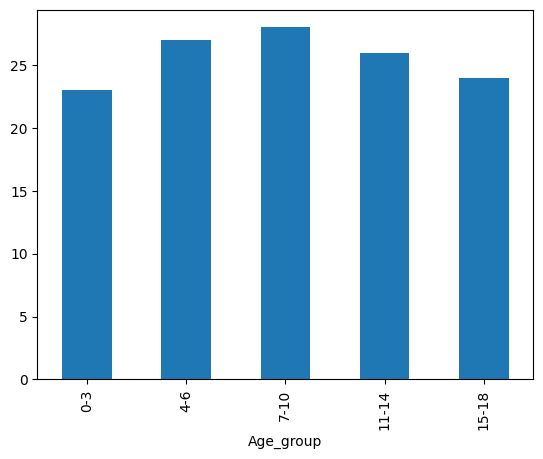

In [ ]:
# Check donor distribution across age groups
mdata_cd8_age["milo"].obs["Age_group"].value_counts().sort_index().plot.bar()

___

## Visualize embedding

In [ ]:
# Build neighbourhood graph for visualising Milo differential abundance results
milo.build_nhood_graph(mdata_cd8_age)

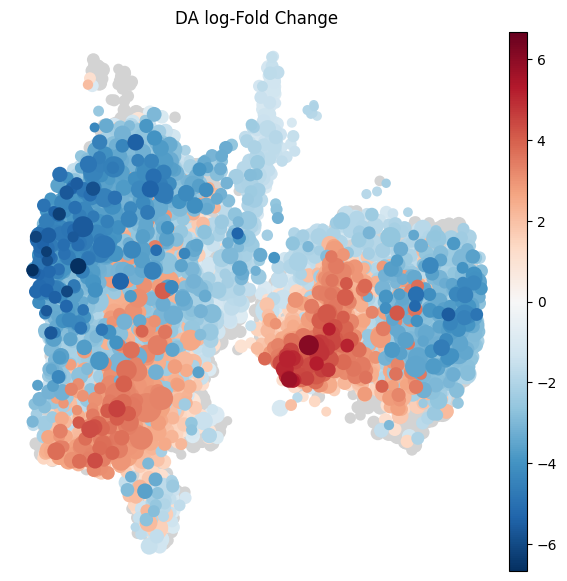

In [ ]:
# Plot neighbourhood-level age-associated logFC values
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd8_age,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

### Annotate Neighbourhoods by Cell Type

In [ ]:
# Assign dominant cell-type annotation to each Milo neighbourhood
milo.annotate_nhoods(mdata_cd8_age, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

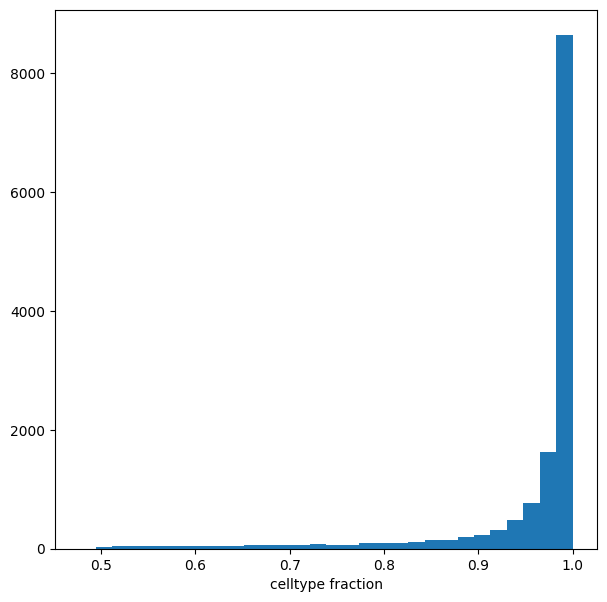

In [ ]:
# Assess annotation purity across neighbourhoods
plt.hist(mdata_cd8_age["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [ ]:
# Label low-purity neighbourhoods as mixed to avoid over-interpreting ambiguous neighbourhoods
mdata_cd8_age["milo"].var["nhood_annotation"] = mdata_cd8_age["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd8_age["milo"].var.loc[mdata_cd8_age["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1014: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nhood_adata.obs[[anno_col, "logFC"]].groupby(anno_col).median().sort_values("logFC", ascending=True).index
/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1031: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1043: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


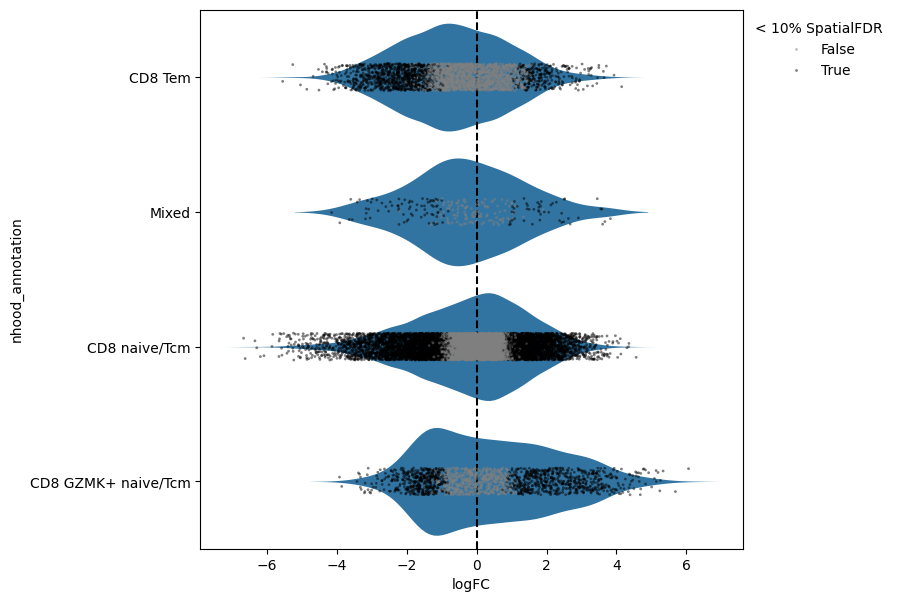

In [ ]:
# Generate beeswarm plot of neighbourhood-level age effects grouped by annotation
milo.plot_da_beeswarm(mdata_cd8_age, alpha=0.1)

In [ ]:
# Extract significant age-associated neighbourhoods
sig_nhoods_cd8_age = mdata_cd8_age["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_cd8_age.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
12075,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,3.332197,5.870527,6.063813,3.786724e-37,5.202580e-33,5.073253e-33,837.0,CD8 GZMK+ naive/Tcm,0.988053
4605,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.576371,3.251513,5.688078,5.278409e-21,4.045827e-18,4.065532e-18,561.0,CD8 GZMK+ naive/Tcm,0.998217
1810,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.810735,2.559272,5.336461,5.907859e-17,1.068001e-14,1.076723e-14,381.0,CD8 GZMK+ naive/Tcm,1.000000
2846,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.659675,2.608601,5.261658,2.233379e-14,1.632149e-12,1.661641e-12,439.0,CD8 GZMK+ naive/Tcm,1.000000
2484,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.683788,3.061385,5.241460,4.496862e-20,1.992980e-17,1.997635e-17,427.0,CD8 GZMK+ naive/Tcm,0.997658


In [12]:
sig_nhoods_cd8_age.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_sig_nhood_age_milo_results.csv")

___

## Diagnostic Visualisation of Age Effects

<Axes: xlabel='logFC', ylabel='kth_distance'>

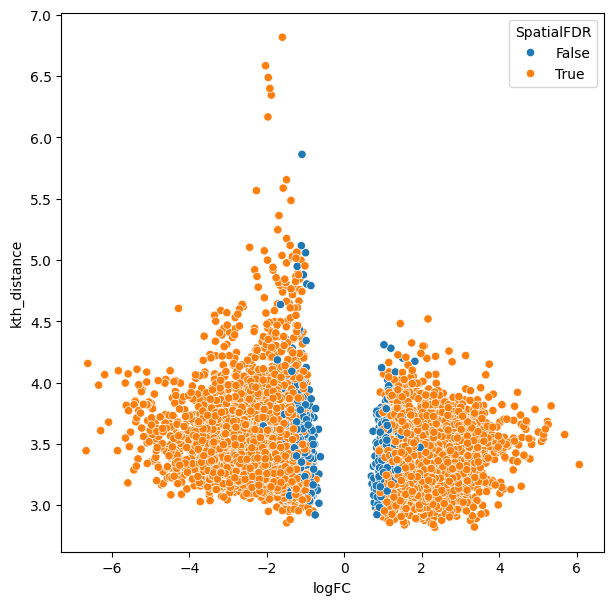

In [ ]:
# Visualise relationship between age-associated logFC and neighbourhood distance
sns.scatterplot(
    data=sig_nhoods_cd8_age,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_cd8_age["SpatialFDR"] < 0.05)
)

___

## Visualization

### Top Age-Associated Neighbourhoods

In [ ]:
# Select top age-enriched neighbourhoods for count plots
pl_nhoods_cd8_age = (
    mdata_cd8_age["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

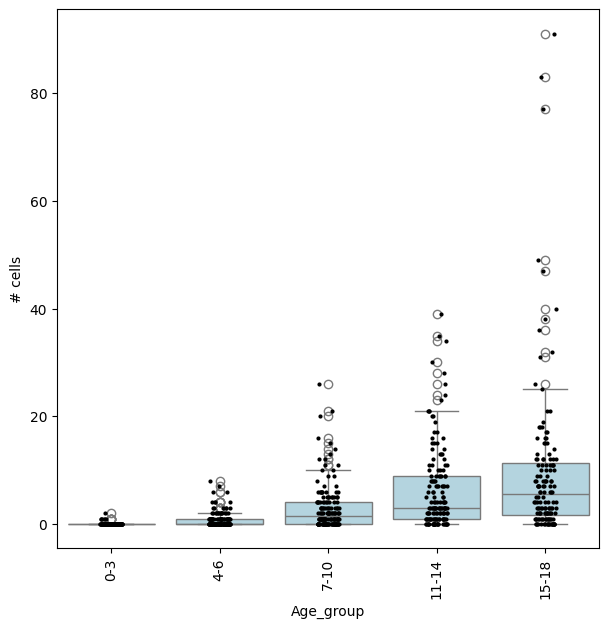

In [ ]:
# Visualise counts by age group for top age-enriched neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd8_age, test_var="Age_group", subset_nhoods=pl_nhoods_cd8_age, log_counts=False)

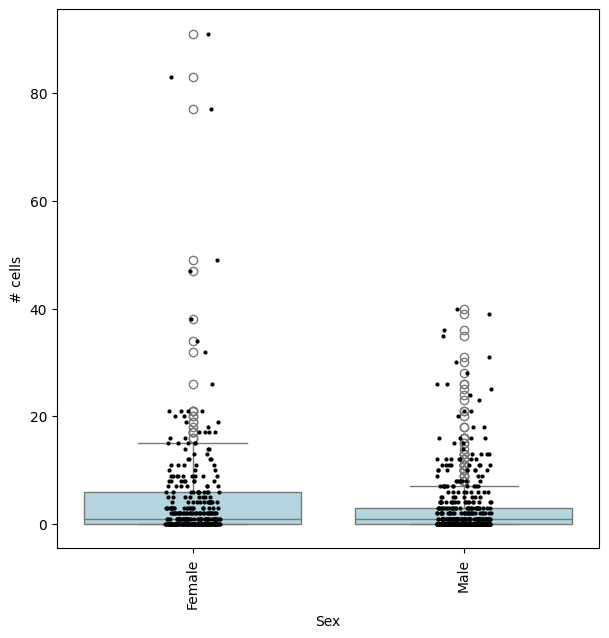

In [ ]:
# Visualise counts by sex for top age-enriched neighbourhoods as an exploratory check
milo.plot_nhood_counts_by_cond(mdata_cd8_age, test_var="Sex", subset_nhoods=pl_nhoods_cd8_age, log_counts=False)

### logFC Distribution by Neighbourhood Annotation

/scratch/temp/24602613/ipykernel_703813/991938354.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cd8_age.groupby("nhood_annotation")["logFC"]
/scratch/temp/24602613/ipykernel_703813/991938354.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_df.groupby(["nhood_annotation", "direction"])


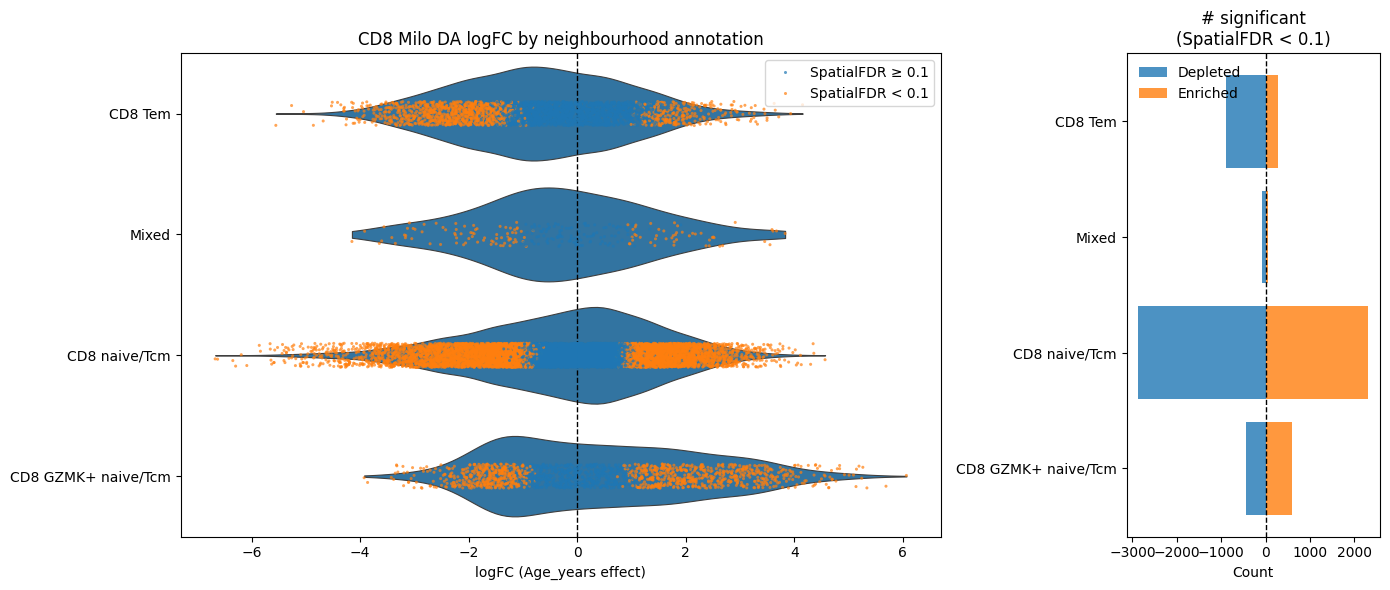

In [18]:
# full nhood results
df_cd8_age = mdata_cd8_age["milo"].var.copy()

# make sure the key columns exist
# df should already have: logFC, SpatialFDR, nhood_annotation
df_cd8_age["sig"] = df_cd8_age["SpatialFDR"] < 0.1

# (optional) order annotations by median logFC (most depleted on top)
order = (
    df_cd8_age.groupby("nhood_annotation")["logFC"]
      .median()
      .sort_values()  # depleted (more negative) first
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_cd8_age, y="nhood_annotation", x="logFC",
    order=order, inner=None, cut=0, linewidth=0.8, ax=axes[0]
)
sns.stripplot(
    data=df_cd8_age, y="nhood_annotation", x="logFC",
    order=order, hue="sig", dodge=False, size=2.2,
    alpha=0.7, ax=axes[0]
)
axes[0].axvline(0, ls="--", c="k", lw=1)
axes[0].set_title("CD8 Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Age_years effect)")
axes[0].set_ylabel("")

# clean up legend (keep only one)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"], title="", loc="upper right")

# ---- Panel B: counts of significant nhoods per annotation ----
sig_df = df_cd8_age[df_cd8_age["sig"]].copy()

# classify direction
sig_df["direction"] = np.where(
    sig_df["logFC"] > 0,
    "Enriched",
    "Depleted"
)

# count neighbourhoods
sig_counts = (
    sig_df.groupby(["nhood_annotation", "direction"])
    .size()
    .unstack(fill_value=0)
    .reindex(order, fill_value=0)
)

# make depleted negative so bars extend left
plot_df = sig_counts.copy()

if "Depleted" in plot_df.columns:
    plot_df["Depleted"] = -plot_df["Depleted"]

# plot depleted
axes[1].barh(
    plot_df.index,
    plot_df.get("Depleted", 0),
    label="Depleted",
    alpha=0.8
)

# plot enriched
axes[1].barh(
    plot_df.index,
    plot_df.get("Enriched", 0),
    label="Enriched",
    alpha=0.8
)

# centre line
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)

axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

# keep same ordering
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order)
axes[1].invert_yaxis()

axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()